Рандом ЛЕС
OOB Accuracy: 0.8061797752808989
OOBE:  0.1938202247191011

Матрица ошибок:
[[93 12]
 [20 54]]
AUC-ROC: 0.9021


Text(0.5, 1.0, 'ROC curve')

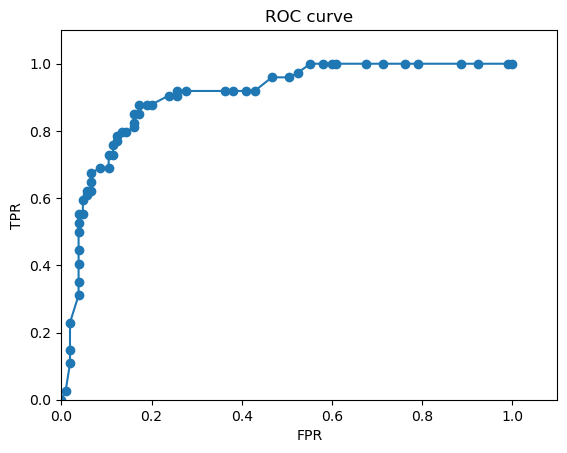

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, roc_curve, auc,  accuracy_score, roc_auc_score, classification_report
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

df = pd.read_csv('processed_titanic.csv')
X1 = df.drop('Survived', axis=1)
y1 = df['Survived']
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

model = RandomForestClassifier(oob_score=True)

model.fit(X1_train, y1_train)

y1_pred = model.predict(X1_test)
y1_proba = model.predict_proba(X1_test)

out_of_bag_probabilities = model.oob_decision_function_
print("Рандом ЛЕС")
print("OOB Accuracy:", model.oob_score_)
print("OOBE: ", 1 - model.oob_score_)


conf_matrix = confusion_matrix(y1_test, y1_pred)
print("\nМатрица ошибок:")
print(conf_matrix)

fpr, tpr, thresholds = roc_curve(y1_test, y1_proba[:, 1])
auc_metric = auc(fpr, tpr)
print(f"AUC-ROC: {auc_metric:.4f}")

plt.plot(fpr, tpr, marker='o')
plt.ylim([0,1.1])
plt.xlim([0,1.1])
plt.ylabel('TPR')
plt.xlabel('FPR')
plt.title('ROC curve')


Точность на тестовой выборке: 0.7989
Отчет по классификации:
              precision    recall  f1-score   support

           0       0.81      0.87      0.83       105
           1       0.79      0.70      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179


Матрица ошибок:
[[93 12]
 [20 54]]
AUC-ROC: 0.8584


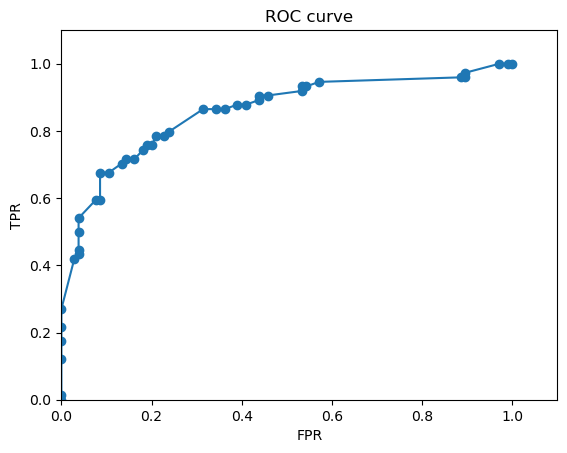

In [22]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

ada_model = AdaBoostClassifier(
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)
ada_model.fit(X1_train, y1_train)
y_pred_ada = ada_model.predict(X1_test)
y_pred_proba_ada = ada_model.predict_proba(X1_test)[:, 1]
accuracy_ada = accuracy_score(y1_test, y_pred_ada)


fpr_ada, tpr_ada, _ = roc_curve(y1_test, y_pred_proba_ada)
roc_auc_ada = auc(fpr_ada, tpr_ada)

print(f"Точность на тестовой выборке: {accuracy_ada:.4f}")
print("Отчет по классификации:")
print(classification_report(y1_test, y_pred_ada))



plt.plot(fpr_ada, tpr_ada, marker='o')
plt.ylim([0,1.1])
plt.xlim([0,1.1])
plt.ylabel('TPR')
plt.xlabel('FPR')
plt.title('ROC curve')
auc_metric = auc(fpr_ada, tpr_ada)
print(f"AUC-ROC: {auc_metric:.4f}")

Точность на тестовой выборке: 0.8045
Отчет по классификации:
AUC-ROC: 0.8719


Text(0.5, 1.0, 'ROC curve')

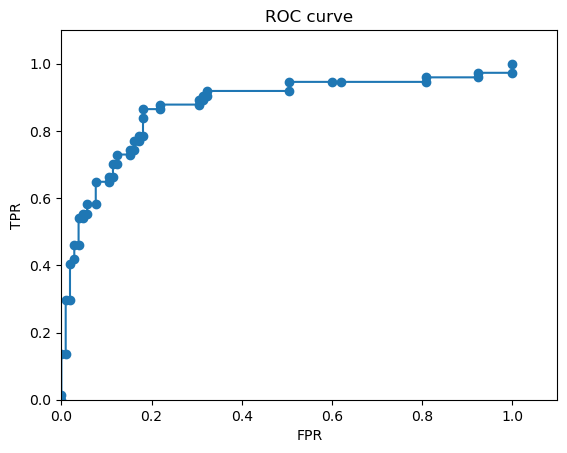

In [20]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
gb_model.fit(X1_train, y1_train)
y_pred_gb = gb_model.predict(X1_test)
y_pred_proba_gb = gb_model.predict_proba(X1_test)[:, 1]
accuracy_gb = accuracy_score(y1_test, y_pred_gb)

fpr_gb, tpr_gb, _ = roc_curve(y1_test, y_pred_proba_gb)
roc_auc_gb = auc(fpr_gb, tpr_gb)

print(f"Точность на тестовой выборке: {accuracy_gb:.4f}")
print("Отчет по классификации:")

auc_metric = auc(fpr_gb, tpr_gb)
print(f"AUC-ROC: {auc_metric:.4f}")
plt.plot(fpr_gb, tpr_gb, marker='o')
plt.ylim([0,1.1])
plt.xlim([0,1.1])
plt.ylabel('TPR')
plt.xlabel('FPR')
plt.title('ROC curve')